In [77]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

In [78]:
df_index = pd.read_csv("economic_index.csv")

In [79]:
df_index.head()

,Unnamed: 0,year,month,interest_rate,unemployment_rate,index_price
0,0,2017,12,2.75,5.3,1464
1,1,2017,11,2.50,5.3,1394
2,2,2017,10,2.50,5.3,1357
3,3,2017,9,2.50,5.3,1293
4,4,2017,8,2.50,5.4,1256


In [80]:
# drop Unnessary columns

# Herre year and month is not required to predict the o/p

df_index.drop(columns = ["Unnamed: 0" , "year" , "month"],axis = 1 , inplace = True)

In [81]:
df_index.isnull().sum()

interest_rate        0
unemployment_rate    0
index_price          0
dtype: int64

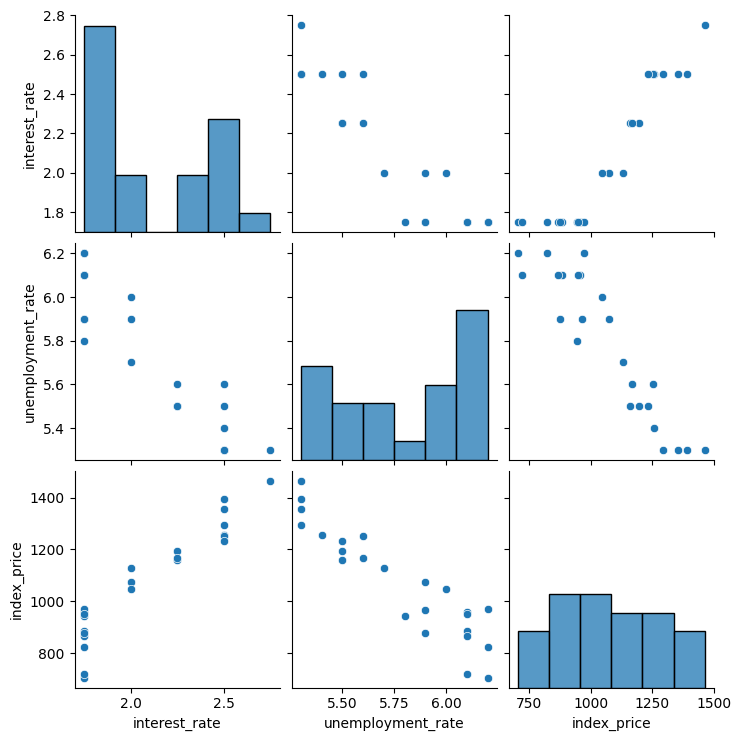

In [82]:
import seaborn as sns

sns.pairplot(df_index)

In [83]:
df_index.corr()

,interest_rate,unemployment_rate,index_price
interest_rate,1.000000,-0.925814,0.935793
unemployment_rate,-0.925814,1.000000,-0.922338
index_price,0.935793,-0.922338,1.000000


Text(0, 0.5, 'Unemployment Rate')

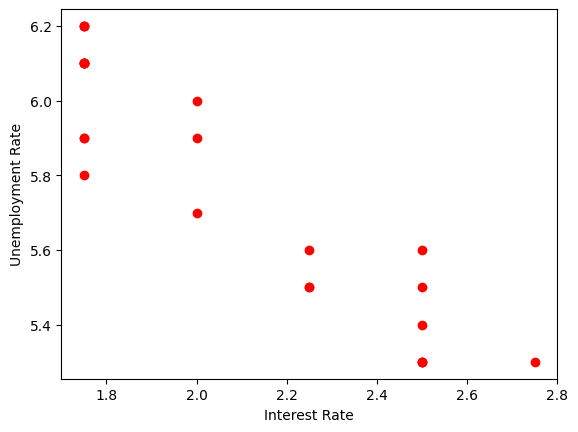

In [84]:
#Visualixe the data more closely

plt.scatter(df_index['interest_rate'],df_index['unemployment_rate'] , color = 'r')
plt.xlabel("Interest Rate")
plt.ylabel("Unemployment Rate")

In [85]:
## Independent and dependent Featues
 
X = df_index[['index_price' , 'unemployment_rate']]  # Another way is == df_index.iloc[:,:-1]
#y = df_index.iloc[:,-1]


y = df_index.iloc[:,-1]

In [86]:
type(X)
type(y)

pandas.core.series.Series

In [87]:
X.head()

,index_price,unemployment_rate
0,1464,5.3
1,1394,5.3
2,1357,5.3
3,1293,5.3
4,1256,5.4


In [88]:
y

0     1464
1     1394
2     1357
3     1293
4     1256
5     1254
6     1234
7     1195
8     1159
9     1167
10    1130
11    1075
12    1047
13     965
14     943
15     958
16     971
17     949
18     884
19     866
20     876
21     822
22     704
23     719
Name: index_price, dtype: int64

In [89]:
# Train test split

from sklearn.model_selection import train_test_split

In [90]:
X_train, X_test , y_train , y_test = train_test_split(X,y,test_size=0.25,random_state=42)

In [91]:
import seaborn as sns

<Axes: xlabel='interest_rate', ylabel='index_price'>

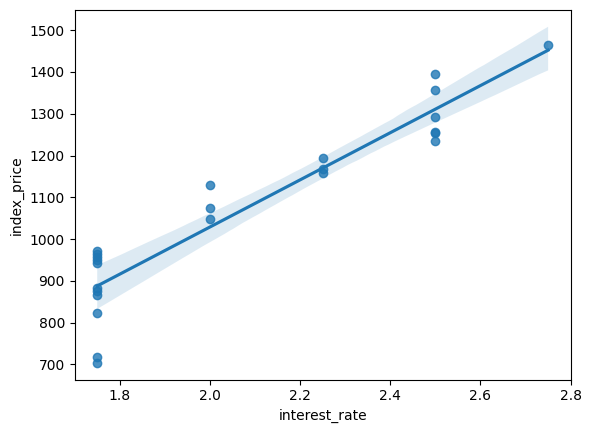

In [92]:
sns.regplot(x='interest_rate', y='index_price', data=df_index)

<Axes: xlabel='interest_rate', ylabel='unemployment_rate'>

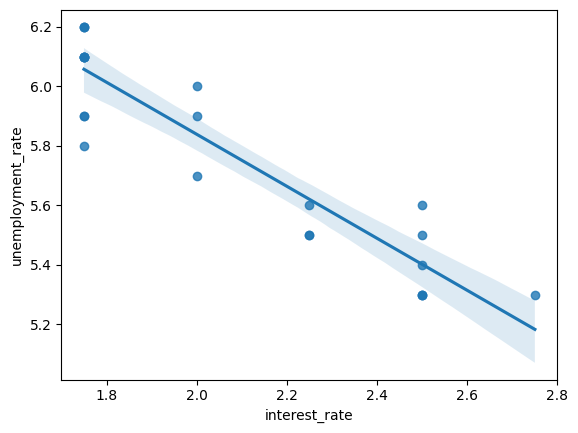

In [93]:
sns.regplot(x='interest_rate', y='unemployment_rate', data=df_index)

In [94]:
## Standardization

from sklearn.preprocessing import StandardScaler

In [95]:
scaler = StandardScaler()


In [96]:

X_train = scaler.fit_transform(X_train)
X_test = scaler.fit_transform(X_test)

In [97]:
X_train

array([[-0.41966146,  0.37908503],
       [ 1.6159075 , -1.48187786],
       [-1.09818444,  1.30956648],
       [ 0.95161926, -0.55139641],
       [ 1.44034561, -1.48187786],
       [-0.03057835,  0.68924552],
       [-0.45287587,  0.999406  ],
       [ 1.13667099, -1.48187786],
       [ 0.96110909, -1.17171738],
       [-1.65808453,  1.30956648],
       [-0.49558011,  0.999406  ],
       [-0.84195898,  0.37908503],
       [-1.58691079,  0.999406  ],
       [ 0.67166922, -0.8615569 ],
       [ 0.36324968, -0.24123593],
       [-0.52404961,  0.06892455],
       [-0.88940814,  0.999406  ],
       [ 0.85672094, -0.8615569 ]])

In [98]:
from sklearn.linear_model import LinearRegression
regression = LinearRegression()

In [99]:
regression.fit(X_train,y_train)

LinearRegression()

In [101]:
from sklearn.model_selection import cross_val_score

validation_score = cross_val_score(regression , X_train , y_train , scoring = 'neg_mean_squared_error',cv=3)

In [103]:
validation_score

array([-2.15411618e-27, -0.00000000e+00, -0.00000000e+00])

In [102]:
np.mean(validation_score)

-7.1803872617450315e-28

In [ ]:
# Prediction